In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


plt.style.use("seaborn-v0_8")

fontsize = 14
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)

colores  = {
    "blue":   "#4C72B0",
    "green":  "#55A868",
    "red":    "#C44E52",
    "purple": "#8172B2",
    "yellow": "#CCB974",
    "cyan":   "#64B5CD",
}
def lineal(P, a, b):
    return a * P + b


Pincho la calibración del fotodiodo, vamos a ver las curvas de eficiencia de las distintas cavidades.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LEER CSV
# ============================================================

archivo = "../datos/MEDICION CAVIDAD PARALELAS - Hoja 1.csv"   # cambiar por tu ruta

df = pd.read_csv(archivo)

print("Columnas encontradas:")
print(df.columns)

print("\nPrimeras filas:")
print(df.head())

Columnas encontradas:
Index(['Corriente [mA]', 'Potencia nd:yag [mW]', 'dPotencia nd:yag [mW]',
       'Potencia bombeo [mW]', 'dPotencia bombeo [mW]'],
      dtype='str')

Primeras filas:
   Corriente [mA]  Potencia nd:yag [mW]  dPotencia nd:yag [mW]  \
0             0.0                  0.90                   0.10   
1             0.2                  1.04                   0.02   
2             0.4                  1.07                   0.01   
3             0.6                  1.10                   0.01   
4             0.8                  2.23                   0.02   

   Potencia bombeo [mW]  dPotencia bombeo [mW]  
0                  1.17                   0.02  
1                  1.16                   0.01  
2                  1.18                   0.02  
3                  1.18                   0.02  
4                  2.36                   0.03  


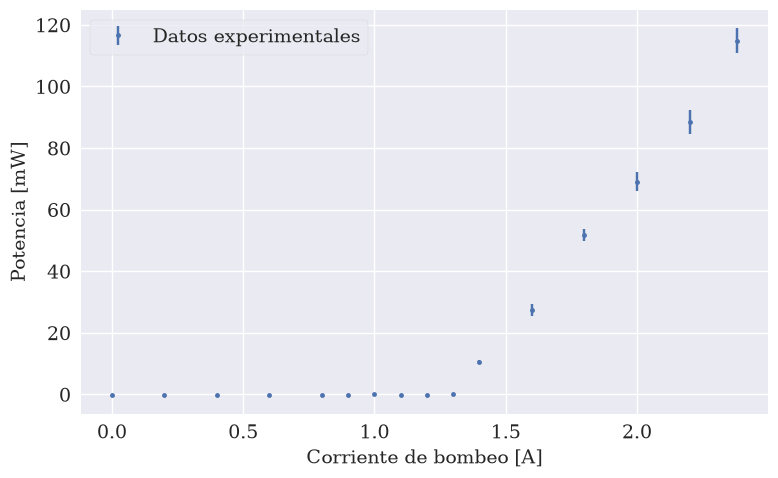

In [4]:
import numpy as np
I = np.array(df['Corriente [mA]'])

Ptot = np.array(df["Potencia nd:yag [mW]"])
Ptot_err = np.array(df["dPotencia nd:yag [mW]"])
Pbomb = np.array(df["Potencia bombeo [mW]"])
Pbomb_err = np.array(df["dPotencia bombeo [mW]"])

P_laser = Ptot - Pbomb

P_laser_err = np.sqrt(Ptot_err**2 + Pbomb_err**2)
# ============================================================
# 3. GRAFICAR
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    I,
    P_laser,
    yerr=P_laser_err,
    fmt=".",
    capsize=3,
    label="Datos experimentales"
)

plt.xlabel("Corriente de bombeo [A]")
plt.ylabel("Potencia [mW]")

plt.legend()
plt.tight_layout()

plt.show()

In [5]:
df_plegada = pd.read_csv("../datos/Barrido potencia plegada plano - Hoja 1.csv", header=1)
print(df_plegada.columns)
print(df_plegada.head())

Index(['Corriente (A)', 'intensiadad  (mW)', 'Error intensidad (mW)',
       'Corriente (A).1', 'intensiadad  (mW).1', 'Error intensidad (mW).1'],
      dtype='str')
   Corriente (A)  intensiadad  (mW)  Error intensidad (mW)  Corriente (A).1  \
0            0.0              1.015                   0.01              0.0   
1            0.2              1.007                   0.01              0.2   
2            0.4              1.008                   0.01              0.4   
3            0.6              1.010                   0.01              0.6   
4            0.8              1.420                   0.02              0.8   

   intensiadad  (mW).1  Error intensidad (mW).1  
0                1.055                     0.01  
1                1.035                     0.01  
2                1.032                     0.01  
3                1.044                     0.01  
4                1.445                     0.01  


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CAVIDAD ORIGINAL
# ============================================================

df = pd.read_csv("../datos/MEDICION CAVIDAD PARALELAS - Hoja 1.csv")

I = np.array(df["Corriente [mA]"])

Ptot = np.array(df["Potencia nd:yag [mW]"])
Ptot_err = np.array(df["dPotencia nd:yag [mW]"])

Pbomb = np.array(df["Potencia bombeo [mW]"])
Pbomb_err = np.array(df["dPotencia bombeo [mW]"])

P_laser = Ptot - Pbomb

P_laser_err = np.sqrt(
    Ptot_err**2 +
    Pbomb_err**2
)


# ============================================================
# 2. CAVIDAD PLEGADA
# ============================================================

df_plegada = pd.read_csv("../datos/Barrido potencia plegada plano - Hoja 1.csv", header=1)

I_plegada = np.array(df_plegada["Corriente (A)"])

Ptot_plegada = np.array(df_plegada["intensiadad  (mW)"])
Ptot_plegada_err = np.array(df_plegada["Error intensidad (mW)"])

Pbomb_plegada = np.array(df_plegada["intensiadad  (mW).1"])
Pbomb_plegada_err = np.array(df_plegada["Error intensidad (mW).1"])

P_laser_plegada = Ptot_plegada - Pbomb_plegada

P_laser_plegada_err = np.sqrt(
    Ptot_plegada_err**2 +
    Pbomb_plegada_err**2
)

In [7]:
archivo = "../datos/Mediciones Laser Bombeo.xlsx"
xls = pd.ExcelFile(archivo)

print(xls.sheet_names)

['INDICE', 'Hoja 1', 'Hoja 2']


In [8]:
df_sin = pd.read_excel(archivo, sheet_name="Hoja 2")

df_con = pd.read_excel(archivo, sheet_name="Hoja 1")

umbral con = 0.647 +- 0.074 A
pendiente con = 156.529 +- 7.848 A
umbral sin = 0.684 +- 0.004 A
pendiente sin = 988.890 +- 2.820 A


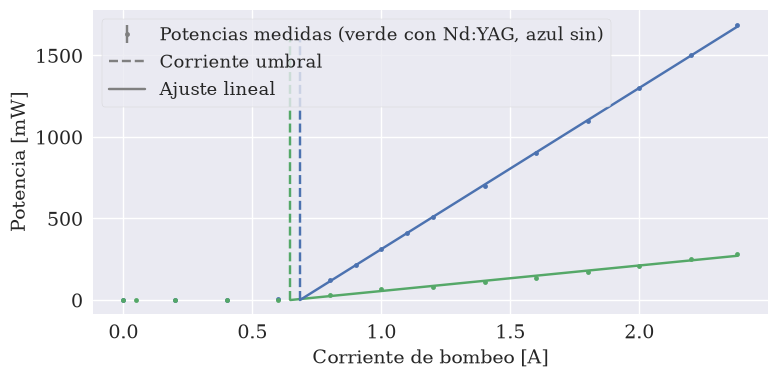

In [11]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# DATOS SIN Nd:YAG
# ============================================================

I_sin = np.array(df_sin["Corriente [mA]"])
P_sin = np.array(df_sin["Potencia [mW]"])
P_sin_err = np.array(df_sin["dPotencia [mW]"])


# ============================================================
# DATOS CON Nd:YAG
# ============================================================

I_con = np.array(df_con["Corriente [mA]"])
P_con = np.array(df_con["Potencia [mW]"])
P_con_err = np.array(df_con["dPotencia [mW]"])

popt_con, pcov_con = curve_fit(
    lineal,
    I_con[I_con>= 0.65],
    P_con[I_con>= 0.65],
)
a_c, b_c = popt_con
Da_c, Db_c =np.sqrt(np.diag(pcov_con))


umbral_con = -popt_con[1]/popt_con[0]
D_umbral_con = np.sqrt((1/a_c * Da_c)**2 + (b_c/a_c**2 * Db_c)**2)
print(f"umbral con = {umbral_con:.3f} +- {D_umbral_con:.3f} A")
print(f"pendiente con = {a_c:.3f} +- {Da_c:.3f} A")

popt_sin, pcov_sin = curve_fit(
    lineal,
    I_sin[I_sin>= 0.65],
    P_sin[I_sin>= 0.65],
)
a_s, b_s = popt_sin
Da_s, Db_s =np.sqrt(np.diag(pcov_sin))

umbral_sin = -popt_sin[1]/popt_sin[0]
D_umbral_sin = np.sqrt((1/a_s * Da_s)**2 + (b_s/a_s**2 * Db_s)**2)
ef_dif_sin, D_ef_dif_sin = a_s, Da_s
print(f"umbral sin = {umbral_sin:.3f} +- {D_umbral_sin:.3f} A")
print(f"pendiente sin = {a_s:.3f} +- {Da_s:.3f} A")



# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot()
plt.errorbar(
    I_sin,
    P_sin,
    yerr=P_sin_err,
    fmt=".",
    # capsize=3,
    label="Potencias medidas (verde con Nd:YAG, azul sin)",
    color = colores["blue"],
)

plt.errorbar(
    I_con,
    P_con,
    yerr=P_con_err,
    fmt=".",
    color = colores["green"],
    # capsize=3,
    # label="Datos con Nd:YAG"
)
Pc = np.linspace(umbral_con, 2.38, 100)
plt.plot(Pc, lineal(Pc, *popt_con), color = colores["green"], label= "Ajuste lineal")


Ps = np.linspace(umbral_sin, 2.38, 100)
plt.plot(Ps, lineal(Ps, *popt_sin), color = colores["blue"])

plt.vlines(umbral_con, 0, 1600, linestyles="--", colors=colores["green"],label = "Corriente umbral")
plt.vlines(umbral_sin, 0, 1600, linestyles="--", colors= colores["blue"])

plt.xlabel("Corriente de bombeo [A]")
plt.ylabel("Potencia [mW]")


handles, labels = plt.gca().get_legend_handles_labels()

legend = plt.legend(handles[::-1], labels[::-1], fontsize = 13)
from matplotlib.lines import Line2D


for handle in legend.legend_handles:
    handle.set_color("gray")

for artist in legend.findobj(Line2D):
    # Only change actual markers
    if artist.get_marker() not in [None, "None", ""]:
        artist.set_markerfacecolor("gray")
        artist.set_markeredgecolor("gray")


plt.tight_layout()

plt.savefig("../figuras/potencia_bombeo.pdf")

umbral plegada = 1.104 +- 0.082 A
pendiente plegada = 148.811 +- 5.365 mW/A
umbral plano-plano = 1.277 +- 0.103 mW/A
pendiente plano-plano = 98.823 +- 4.087 A


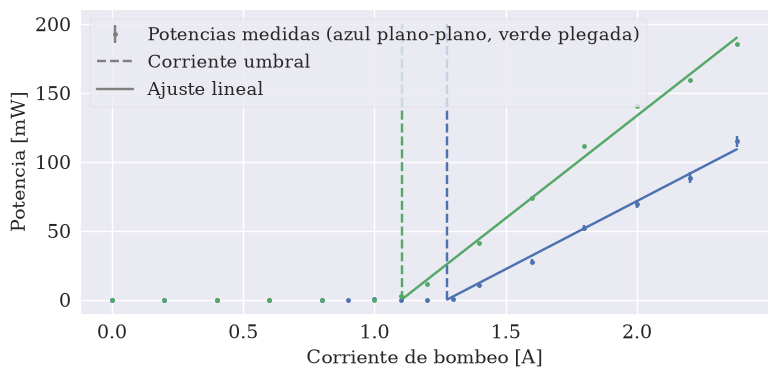

In [10]:
import numpy as np
import matplotlib.pyplot as plt
"""Asociamps sin -> normal, con -> plegada """

# ============================================================
# DATOS SIN Nd:YAG
# ============================================================

I_sin = I
P_sin = P_laser
P_sin_err = P_laser_err


# ============================================================
# DATOS CON Nd:YAG
# ============================================================

I_con = I_plegada
P_con = P_laser_plegada
P_con_err = P_laser_plegada_err

popt_con, pcov_con = curve_fit(
    lineal,
    I_con[I_con>= 1.2],
    P_con[I_con>= 1.2],
)
a_c, b_c = popt_con
Da_c, Db_c =np.sqrt(np.diag(pcov_con))


umbral_con = -popt_con[1]/popt_con[0]
D_umbral_con = np.sqrt((1/a_c * Da_c)**2 + (b_c/a_c**2 * Db_c)**2)
ef_dif_plegada, D_ef_dif_plegada = a_c, Da_c
print(f"umbral plegada = {umbral_con:.3f} +- {D_umbral_con:.3f} A")
print(f"pendiente plegada = {a_c:.3f} +- {Da_c:.3f} mW/A")

popt_sin, pcov_sin = curve_fit(
    lineal,
    I_sin[I_sin>= 1.2],
    P_sin[I_sin>= 1.2],
)
a_s, b_s = popt_sin
Da_s, Db_s =np.sqrt(np.diag(pcov_sin))

umbral_sin = -popt_sin[1]/popt_sin[0]
D_umbral_sin = np.sqrt((1/a_s * Da_s)**2 + (b_s/a_s**2 * Db_s)**2)
ef_dif_plano, D_ef_dif_plano = a_s, Da_s
print(f"umbral plano-plano = {umbral_sin:.3f} +- {D_umbral_sin:.3f} mW/A")
print(f"pendiente plano-plano = {a_s:.3f} +- {Da_s:.3f} A")



# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot()
plt.errorbar(
    I_sin,
    P_sin,
    yerr=P_sin_err,
    fmt=".",
    # capsize=3,
    label="Potencias medidas (azul plano-plano, verde plegada)",
    color = colores["blue"],
)

plt.errorbar(
    I_con,
    P_con,
    yerr=P_con_err,
    fmt=".",
    color = colores["green"],
    # capsize=3,
    # label="Datos con Nd:YAG"
)
Pc = np.linspace(umbral_con, 2.38, 100)
plt.plot(Pc, lineal(Pc, *popt_con), color = colores["green"], label= "Ajuste lineal")


Ps = np.linspace(umbral_sin, 2.38, 100)
plt.plot(Ps, lineal(Ps, *popt_sin), color = colores["blue"])

plt.vlines(umbral_con, 0, 200, linestyles="--", colors=colores["green"], label = "Corriente umbral")
plt.vlines(umbral_sin, 0, 200, linestyles="--", colors= colores["blue"])

plt.xlabel("Corriente de bombeo [A]")
plt.ylabel("Potencia [mW]")


handles, labels = plt.gca().get_legend_handles_labels()

legend = plt.legend(handles[::-1], labels[::-1], fontsize = 13)
from matplotlib.lines import Line2D


for handle in legend.legend_handles:
    handle.set_color("gray")

for artist in legend.findobj(Line2D):
    # Only change actual markers
    if artist.get_marker() not in [None, "None", ""]:
        artist.set_markerfacecolor("gray")
        artist.set_markeredgecolor("gray")


plt.tight_layout()

plt.savefig("../figuras/respuesta_en_potencia.pdf")

In [20]:
ef_plano = ef_dif_plano/ ef_dif_sin
D_ef_plano = np.sqrt((1/ef_dif_sin * D_ef_dif_plano)**2 + (ef_dif_plano/ef_dif_sin**2 * D_ef_dif_sin)**2)
print(f"Eficiencia plano-plano = {ef_plano:.3f} +- {D_ef_plano:.3f}")


ef_plegada = ef_dif_plegada/ ef_dif_sin
D_ef_plegada = np.sqrt((1/ef_dif_sin * D_ef_dif_plegada)**2 + (ef_dif_plegada/ef_dif_sin**2 * D_ef_dif_sin)**2)
print(f"Eficiencia plegada= {ef_plegada:.3f} +- {D_ef_plegada:.3f}")

Eficiencia plano-plano = 0.100 +- 0.004
Eficiencia plegada= 0.150 +- 0.005
